In [4]:
import sys

from sqlglot import parse_one
from sqlglot.lineage import lineage
from sqlglot.optimizer.qualify import qualify
from sqlglot.optimizer.scope import build_scope

# from lineage import LineageGraph

target_query = """
               WITH cte AS (SELECT a.traced_col
                            FROM (SELECT id, traced_col
                                  FROM intermediate) a
                                   JOIN
                                 intermdeidate b
                                 ON a.id = b.id)
               SELECT traced_col
               FROM cte
               """

ast = parse_one(target_query)
scopes = build_scope(ast)

for scope in scopes.traverse():
    print(repr(scope))


Scope<SELECT id, traced_col FROM intermediate>
Scope<SELECT a.traced_col FROM (SELECT id, traced_col FROM intermediate) AS a JOIN intermdeidate AS b ON a.id = b.id>
Scope<WITH cte AS (SELECT a.traced_col FROM (SELECT id, traced_col FROM intermediate) AS a JOIN intermdeidate AS b ON a.id = b.id) SELECT traced_col FROM cte>


In [ ]:
sql = """
WITH cte AS (SELECT id
    FROM cteTable
    WHERE val < 10)

SELECT a.col, b.col + b.price, a.*
FROM
    (SELECT id, col
    FROM tablea
    ) a
    JOIN tableb b ON a.id = b.id
    JOIN cte c ON a.id = c.id
      """

ast = parse_one(sql)
ast = qualify(ast)
scopes = build_scope(ast)

for scope in scopes.traverse():
    print(repr(scope))

In [ ]:
from sqlglot import exp
scopes.expression.selects

In [ ]:
for column in scopes.expression.selects[1].find_all(exp.Column):
    print(repr(column))

In [ ]:
sql = """
WITH CTE AS (SELECT id
    FROM cteTable
    WHERE val < 10)
SELECT price
FROM priceTable p
    INNER JOIN
    CTE c ON p.id = c.id
"""

recursive = """
WITH DirectReports (ManagerID, EmployeeID, Title, DeptID, Level)
AS (
-- Anchor member definition
SELECT e.ManagerID,
           e.EmployeeID,
           e.Title,
           edh.DepartmentID,
           0 AS Level
    FROM dbo.MyEmployees AS e
         INNER JOIN HumanResources.EmployeeDepartmentHistory AS edh
             ON e.EmployeeID = edh.BusinessEntityID
            AND edh.EndDate IS NULL
    WHERE ManagerID IS NULL
    UNION ALL
-- Recursive member definition
    SELECT e.ManagerID,
           e.EmployeeID,
           e.Title,
           edh.DepartmentID,
           Level + 1
    FROM dbo.MyEmployees AS e
         INNER JOIN HumanResources.EmployeeDepartmentHistory AS edh
             ON e.EmployeeID = edh.BusinessEntityID
            AND edh.EndDate IS NULL
         INNER JOIN DirectReports AS d
             ON e.ManagerID = d.EmployeeID)
-- Statement that executes the CTE
SELECT ManagerID,
       EmployeeID,
       Title,
       DeptID,
       Level
FROM DirectReports
     INNER JOIN HumanResources.Department AS dp
         ON DirectReports.DeptID = dp.DepartmentID
WHERE dp.GroupName = N'Sales and Marketing'
      OR Level = 0

"""

astre = parse_one(recursive)
rescope = build_scope(astre)

In [ ]:
rescope.sources['DirectReports']

In [ ]:
lineage("price", sql)

In [6]:
from sqlglot import parse_one
from sqlglot.lineage import lineage


sql = """
WITH valid_paid_orders AS (
    SELECT
        o.order_id,
        o.customer_id,
        COALESCE(o.amount, 0) AS amount
    FROM raw_orders o
),

customer_metrics AS (
    SELECT
        vpo.customer_id,
        COUNT(vpo.order_id) AS total_orders,
        SUM(vpo.amount) AS total_revenue
    FROM valid_paid_orders vpo
    GROUP BY vpo.customer_id
),

customer_names AS (
    SELECT
        customer_id,
        customer_name
    FROM raw_customers
),

final_customer_profile AS (
    SELECT
        cm.customer_id,
        cm.total_orders,
        cm.total_revenue,
    FROM customer_metrics cm
)

SELECT
    *
FROM final_customer_profile a
JOIN bi b
    ON a.customer_id = b.id


"""

node = lineage("*", sql)

In [7]:
with open("lineage_graph.html", "w") as f:
    f.write(str(node.to_html()))

In [18]:
for table in lm.tableNodeMap.values():
    cur = id(table.scope)
    par = id(table.scope.parent)

    print(f"{table.name} cur: {cur}, par: {par}")

Scope_1 cur: 4504440784, par: 4348318000
cleaned_orders cur: 4508770192, par: 4504440784
raw_orders cur: 4508644048, par: 4508644944
valid_orders cur: 4508716304, par: 4504440784
orders_with_payments cur: 4509025424, par: 4504440784
raw_payments cur: 4508859600, par: 4508879568
paid_orders cur: 4509030224, par: 4504440784
customer_aggregates cur: 4509031632, par: 4504440784
customer_enriched cur: 4509033104, par: 4504440784
raw_customers cur: 4508930384, par: 4508931280
customer_segmented cur: 4509034448, par: 4504440784


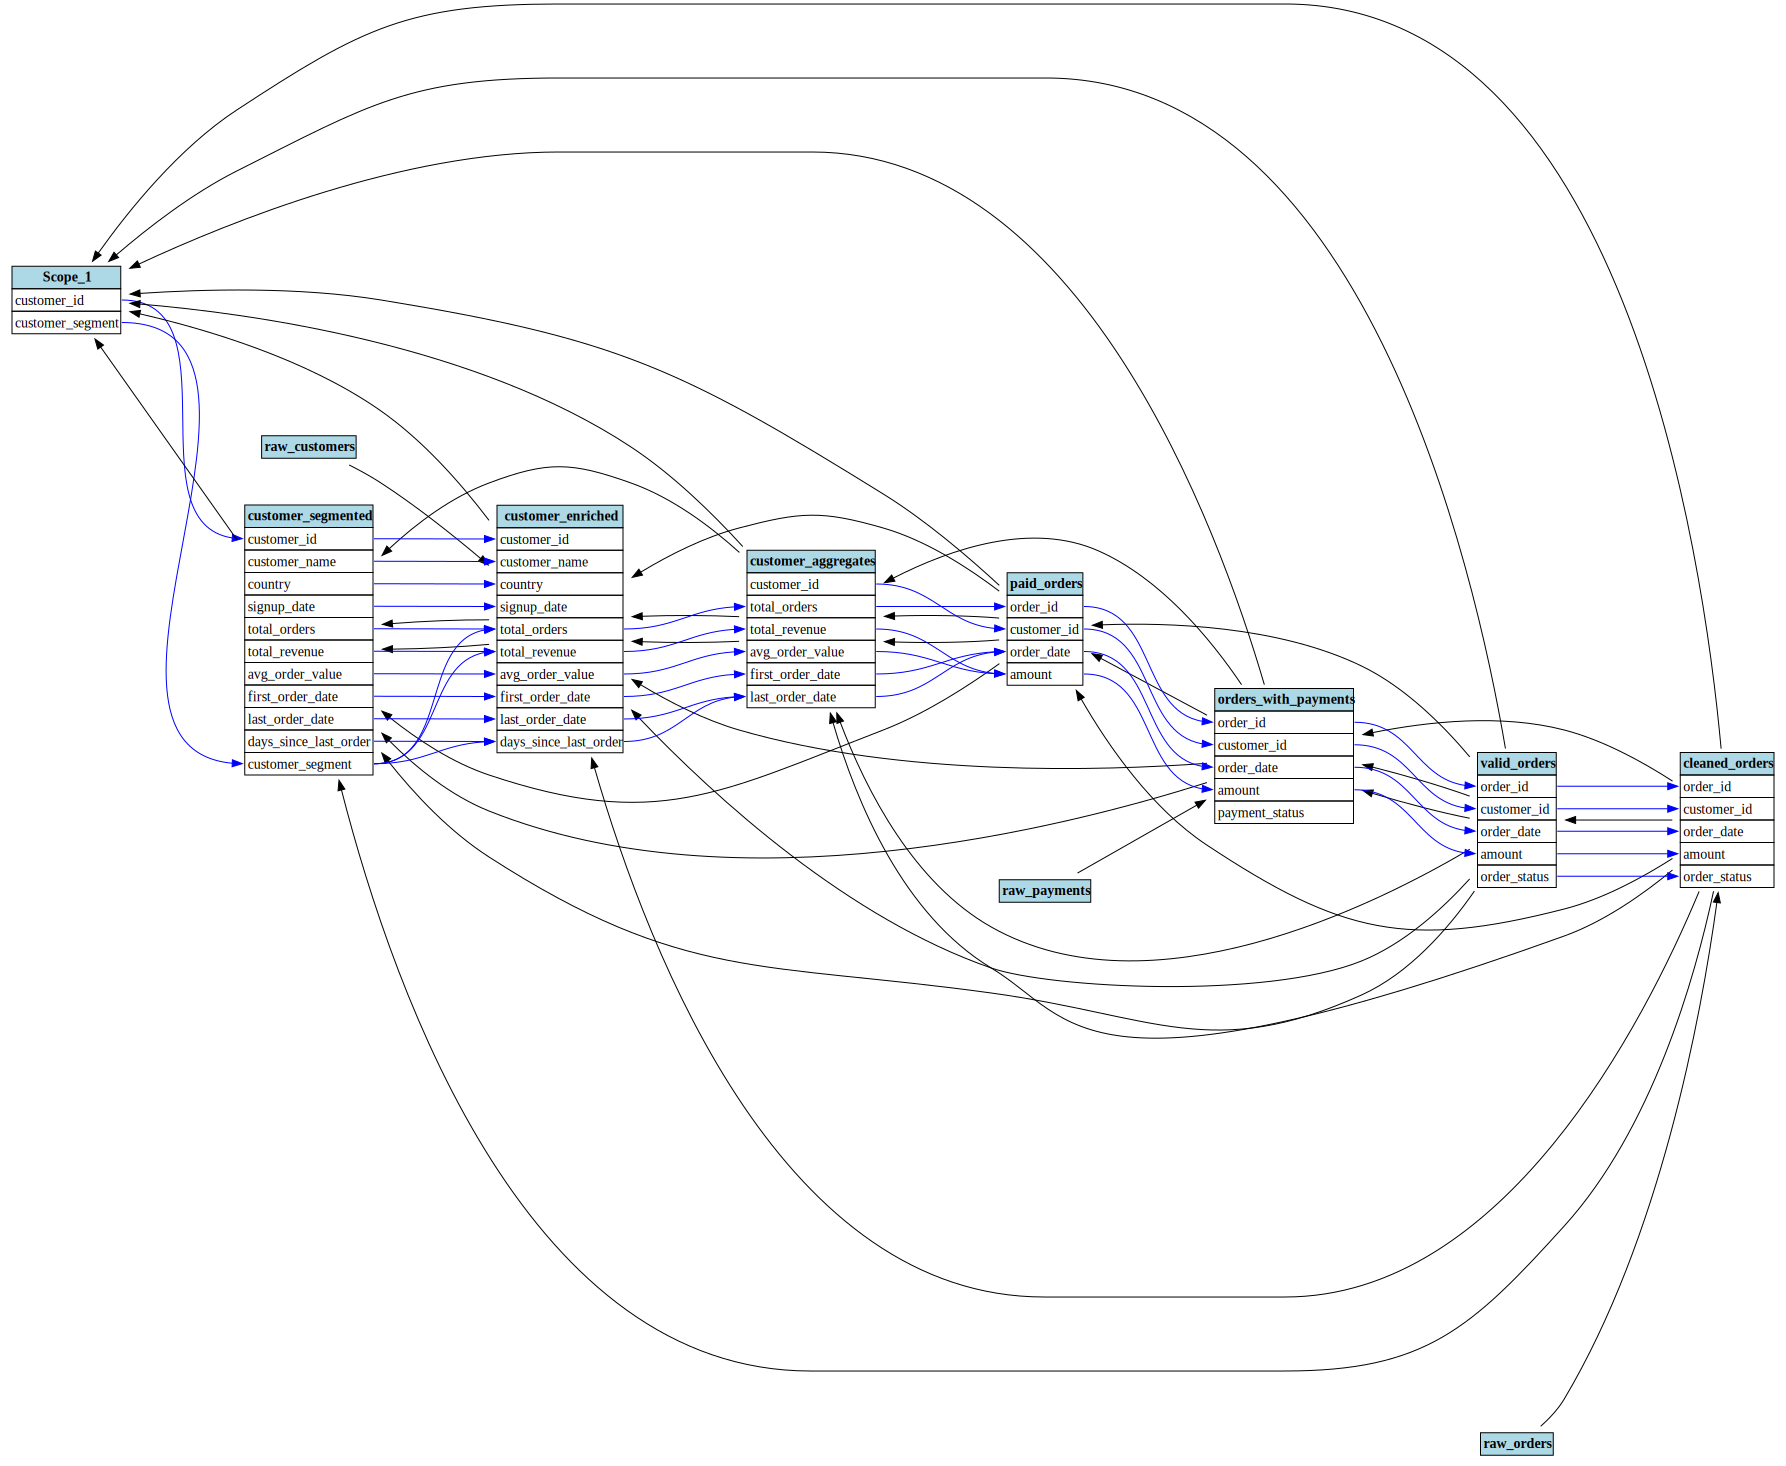

In [2]:
lm.visualize()

In [1]:
from sqlglot.optimizer.scope import build_scope
from sqlglot import parse_one
from sqlglot.optimizer.qualify import qualify
from sqlglot.lineage import lineage, GraphHTML
from sqlglot import exp
from lineage import LineageMap
sql = """
WITH cleaned_orders AS (
    SELECT
        o.order_id,
        o.customer_id,
        CAST(o.order_ts AS DATE) AS order_date,
        COALESCE(o.amount, 0) AS amount,
        o.status AS order_status
    FROM db.raw_orders o
    WHERE o.order_ts IS NOT NULL
),

valid_orders AS (
    SELECT
        order_id,
        customer_id,
        order_date,
        amount,
        order_status
    FROM cleaned_orders
    WHERE order_status IN ('paid', 'shipped', 'completed')
),

orders_with_payments AS (
    SELECT
        vo.order_id,
        vo.customer_id,
        vo.order_date,
        vo.amount,
        p.payment_status
    FROM valid_orders vo
    LEFT JOIN raw_payments p
        ON vo.order_id = p.order_id
),

paid_orders AS (
    SELECT
        order_id,
        customer_id,
        order_date,
        amount
    FROM orders_with_payments
    WHERE payment_status = 'success'
),

customer_aggregates AS (
    SELECT
        po.customer_id,
        COUNT(po.order_id) AS total_orders,
        SUM(po.amount) AS total_revenue,
        AVG(po.amount) AS avg_order_value,
        MIN(po.order_date) AS first_order_date,
        MAX(po.order_date) AS last_order_date
    FROM paid_orders po
    GROUP BY po.customer_id
),

customer_enriched AS (
    SELECT
        c.customer_id,
        c.customer_name,
        c.country,
        c.signup_date,
        ca.total_orders,
        ca.total_revenue,
        ca.avg_order_value,
        ca.first_order_date,
        ca.last_order_date,
        (CURRENT_DATE - ca.last_order_date) AS days_since_last_order
    FROM raw_customers c
    LEFT JOIN customer_aggregates ca
        ON c.customer_id = ca.customer_id
),

customer_segmented AS (
    SELECT
        ce.customer_id,
        ce.customer_name,
        ce.country,
        ce.signup_date,
        COALESCE(ce.total_orders, 0) AS total_orders,
        COALESCE(ce.total_revenue, 0) AS total_revenue,
        ce.avg_order_value,
        ce.first_order_date,
        ce.last_order_date,
        ce.days_since_last_order,
        CASE
            WHEN ce.total_revenue >= 10000 THEN 'VIP'
            WHEN ce.days_since_last_order > 180 THEN 'Churn Risk'
            WHEN ce.total_orders >= 5 THEN 'Regular'
            ELSE 'New'
        END AS customer_segment
    FROM customer_enriched ce
)

SELECT
        cs.customer_id,
    cs.customer_name,
    cs.country,
    cs.signup_date,
FROM customer_segmented cs
"""

ast_sql = qualify(parse_one(sql))
scopes_sql = build_scope(ast_sql)



In [2]:
ast_sql.selects

[Alias(
   this=Column(
     this=Identifier(this='customer_id', quoted=True),
     table=Identifier(this='cs', quoted=True)),
   alias=Identifier(this='customer_id', quoted=True)),
 Alias(
   this=Column(
     this=Identifier(this='customer_name', quoted=True),
     table=Identifier(this='cs', quoted=True)),
   alias=Identifier(this='customer_name', quoted=True)),
 Alias(
   this=Column(
     this=Identifier(this='country', quoted=True),
     table=Identifier(this='cs', quoted=True)),
   alias=Identifier(this='country', quoted=True)),
 Alias(
   this=Column(
     this=Identifier(this='signup_date', quoted=True),
     table=Identifier(this='cs', quoted=True)),
   alias=Identifier(this='signup_date', quoted=True))]

In [2]:
l = LineageMap()
l.parse_sql(sql)

Column order_id not found in downstream table db.raw_orders
Column customer_id not found in downstream table db.raw_orders
Column order_ts not found in downstream table db.raw_orders
Column amount not found in downstream table db.raw_orders
Column status not found in downstream table db.raw_orders
Column payment_status not found in downstream table raw_payments
Column customer_id not found in downstream table raw_customers
Column customer_name not found in downstream table raw_customers
Column country not found in downstream table raw_customers
Column signup_date not found in downstream table raw_customers


In [4]:
l.tableNodeMap

{'Scope_1': <lineage.TableNode at 0x10a636790>,
 'cleaned_orders': <lineage.TableNode at 0x10a69a0d0>,
 'valid_orders': <lineage.TableNode at 0x109edbcd0>,
 'orders_with_payments': <lineage.TableNode at 0x10a698a90>,
 'paid_orders': <lineage.TableNode at 0x10a69bb10>,
 'customer_aggregates': <lineage.TableNode at 0x10a658e90>,
 'customer_enriched': <lineage.TableNode at 0x10a687a10>,
 'customer_segmented': <lineage.TableNode at 0x10a658790>}

In [5]:
create_table = """
CREATE TABLE persons (
    PersonID INT PRIMARY KEY,
    LastName VARCHAR(255) NOT NULL,
    FirstName VARCHAR(255),
    Address VARCHAR(255),
    City VARCHAR(255)
);
"""

ast_create=  qualify(parse_one(create_table))
l.extend_table(ast_create)

In [6]:
create_table_orders = """
CREATE TABLE db.raw_orders (
    Order_ID INT PRIMARY KEY,
    Customer_ID INT NOT NULL REFERENCES persons(PersonID),
    OrderDate DATE NOT NULL,
    Quantity INT NOT NULL
);

"""

ast_create=  qualify(parse_one(create_table_orders))
l.extend_table(ast_create)

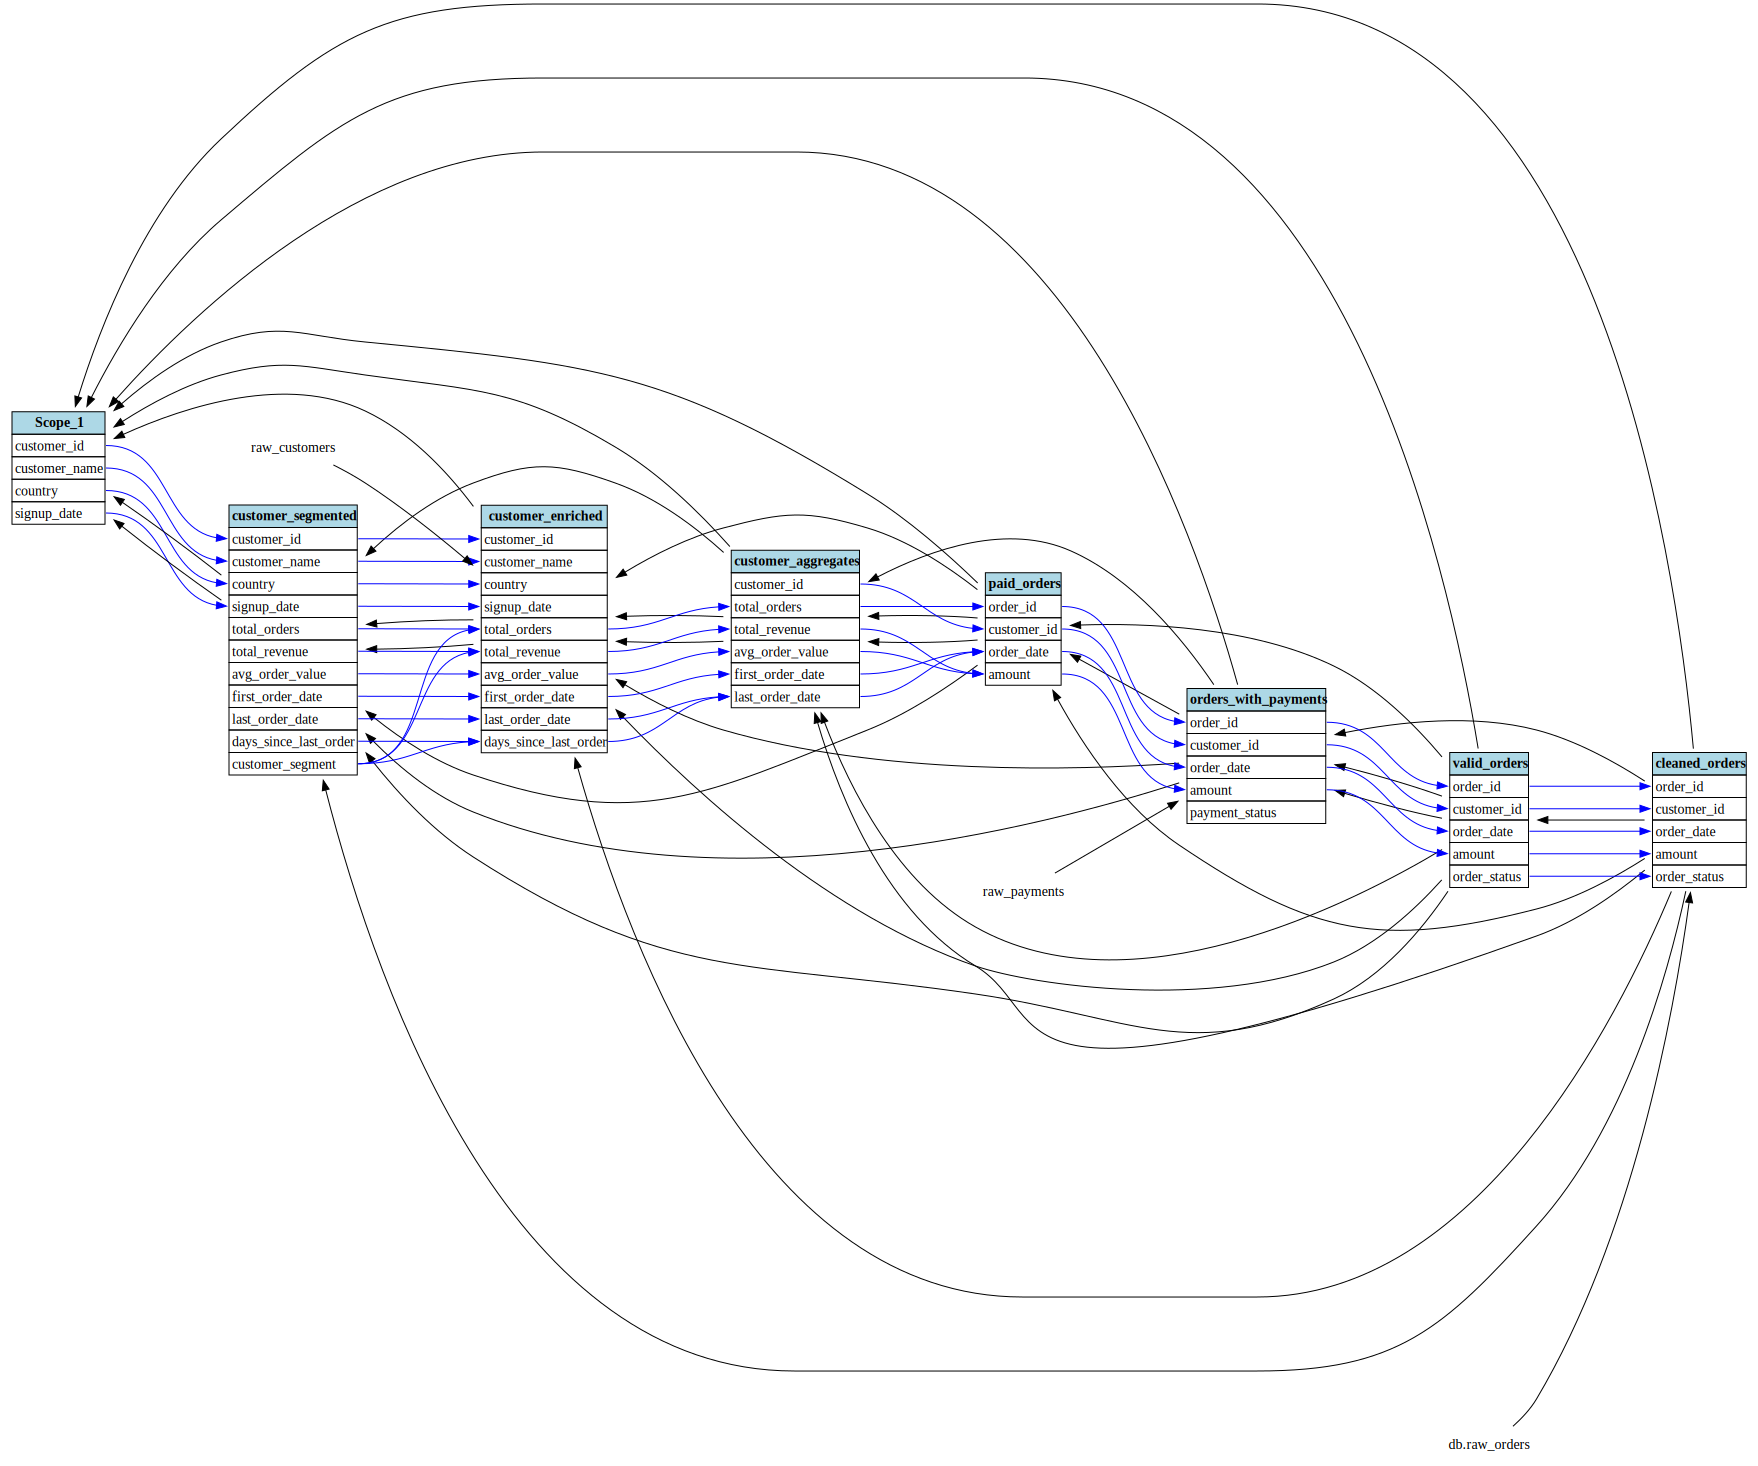

In [3]:
l.visualize()

In [ ]:
from sqlglot.lineage import lineage
from IPython.display import HTML, display

In [17]:
l.tableNodeMap['Scope_1'].scope.sources

{'persons': Table(
   this=Identifier(this='persons', quoted=True),
   alias=TableAlias(
     this=Identifier(this='persons', quoted=True)))}

In [25]:
sql = """
SELECT employee_id, name, salary, department
FROM (
    SELECT employee_id, name, salary, department
    FROM (
        -- Level 3 (innermost): base filter
        SELECT employee_id, name, salary, department
        FROM employees
        WHERE salary > 50000
    ) AS high_paid
    -- Level 2: compare against aggregate from another subquery
    WHERE salary < (
        SELECT AVG(salary)
        FROM (
            SELECT salary
            FROM employees
            WHERE salary > 50000
        ) AS avg_base
    )
) AS filtered
-- Level 1 (outermost): final business filter
WHERE department = 'IT';

"""


ast_sql = qualify(parse_one(sql))
scopes_sql = build_scope(ast_sql)



In [29]:
node = lineage("customer_id", sql)

In [24]:
for x in scopes_sql.sources.keys():
    print(x)

filtered


In [30]:
with open("lineage_graph.html", "w") as f:
    f.write(str(node.to_html()))
display(HTML(str(node.to_html())))

In [8]:
from sqlglot.optimizer.scope import build_scope
from sqlglot import parse_one
from sqlglot.optimizer.qualify import qualify

schema = """SELECT name
FROM db1.cus.customer
"""

ast_schema = parse_one(schema)
scope_ast = build_scope(ast_schema)


In [21]:
ast_schema.find(exp.Table)

Table(
  this=Identifier(this=customer, quoted=False),
  db=Identifier(this=cus, quoted=False),
  catalog=Identifier(this=db1, quoted=False))